Imports and pipeline

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.sentiment.pipeline import run_sentiment_pipeline
from src.data.database import (
    load_features_with_sentiment,
    load_prices,
    initialise_database
)
from src.models.features import time_series_split
from src.models.xgboost_model import train_xgboost

TICKER    = "RELIANCE.NS"
WATCHLIST = [
    "RELIANCE.NS","TCS.NS","INFY.NS",
    "HDFCBANK.NS","WIPRO.NS"
]

# Reinitialise DB to create the sentiment table
initialise_database()
print("DB initialised with sentiment table.")

Database initialised.
  Host: localhost:5432
  DB  : investiq
DB initialised with sentiment table.


Running sentiment pipeline

In [3]:
results = run_sentiment_pipeline(WATCHLIST, days_back=30)

Loading FinBERT model (downloads ~500MB on first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  FinBERT loaded on cpu

─────────────────────────────────────────────
Sentiment pipeline: RELIANCE.NS
  Fetched 50 articles for RELIANCE.NS (2026-06-08 → 2026-07-08)
  Scoring 50 articles with FinBERT...
  Score range: -0.960 to 0.932
  Saved sentiment for RELIANCE.NS
  3d sentiment today: nan
  Momentum today    : nan
  ✓ RELIANCE.NS complete

─────────────────────────────────────────────
Sentiment pipeline: TCS.NS
  Fetched 50 articles for TCS.NS (2026-06-08 → 2026-07-08)
  Scoring 50 articles with FinBERT...
  Score range: -0.966 to 0.934
  Saved sentiment for TCS.NS
  3d sentiment today: 0.389
  Momentum today    : 0.590
  ✓ TCS.NS complete

─────────────────────────────────────────────
Sentiment pipeline: INFY.NS
  Fetched 50 articles for INFY.NS (2026-06-08 → 2026-07-08)
  Scoring 50 articles with FinBERT...
  Score range: -0.964 to 0.922
  Saved sentiment for INFY.NS
  3d sentiment today: nan
  Momentum today    : nan
  ✓ INFY.NS complete

──────────────────────────────────────

Loading and inspecting sentiment features

In [4]:
df = load_features_with_sentiment(TICKER)

print(f"Total rows    : {len(df)}")
print(f"Columns       : {list(df.columns)}")
print(f"\nSentiment statistics:")
print(df[["sentiment_1d","sentiment_3d",
          "sentiment_7d","sentiment_momentum"]
    ].describe().round(4))

# How many days have non-zero sentiment?
non_zero = (df["sentiment_1d"] != 0).sum()
print(f"\nDays with actual sentiment data: {non_zero}/{len(df)}")
print(f"Days with no news (padded 0)   : {len(df) - non_zero}/{len(df)}")

Total rows    : 450
Columns       : ['close', 'sma_20', 'sma_50', 'ema_20', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct', 'volume_ratio', 'sentiment_1d', 'sentiment_3d', 'sentiment_7d', 'sentiment_momentum']

Sentiment statistics:
       sentiment_1d  sentiment_3d  sentiment_7d  sentiment_momentum
count         450.0         450.0         450.0               450.0
mean            0.0           0.0           0.0                 0.0
std             0.0           0.0           0.0                 0.0
min             0.0           0.0           0.0                 0.0
25%             0.0           0.0           0.0                 0.0
50%             0.0           0.0           0.0                 0.0
75%             0.0           0.0           0.0                 0.0
max             0.0           0.0           0.0                 0.0

Days with actual sentiment data: 0/450
Days with no news (padded 0)   : 450/450


Comparing model with and without sentiment

In [5]:
HORIZON   = 10
THRESHOLD = 0.0

def build_dataset_from_df(df, horizon, threshold):
    """Build X, y from a features DataFrame."""
    future_close  = df["close"].shift(-horizon)
    future_return = (future_close - df["close"]) / df["close"]
    y = (future_return > threshold).astype(int)

    df["price_vs_sma20"] = df["close"] / df["sma_20"] - 1
    df["price_vs_sma50"] = df["close"] / df["sma_50"] - 1
    df["rsi_normalized"] = (df["rsi"] - 50) / 50

    base_cols = [
        "rsi","macd","macd_signal","macd_hist",
        "bb_pct","bb_width","sma_20","sma_50",
        "ema_20","volume_ratio",
        "price_vs_sma20","price_vs_sma50","rsi_normalized"
    ]
    sent_cols = [
        "sentiment_1d","sentiment_3d",
        "sentiment_7d","sentiment_momentum"
    ]

    X_base = df[base_cols].copy()
    X_full = df[base_cols + sent_cols].copy()

    X_base = X_base.iloc[:-horizon]
    X_full = X_full.iloc[:-horizon]
    y      = y.iloc[:-horizon]

    valid_base = X_base.notna().all(axis=1) & y.notna()
    valid_full = X_full.notna().all(axis=1) & y.notna()

    return (X_base[valid_base], y[valid_base],
            X_full[valid_full], y[valid_full])

X_base, y_base, X_full, y_full = build_dataset_from_df(
    df, HORIZON, THRESHOLD
)

print(f"Base features  : {X_base.shape[1]} columns")
print(f"Full features  : {X_full.shape[1]} columns")
print(f"Base samples   : {len(X_base)}")
print(f"Full samples   : {len(X_full)}")

Base features  : 13 columns
Full features  : 17 columns
Base samples   : 440
Full samples   : 440


Train both models and compare

In [6]:
# Without sentiment
X_tr_b, X_te_b, y_tr_b, y_te_b = time_series_split(
    X_base, y_base, 0.2
)
print("Training WITHOUT sentiment...")
_, metrics_base = train_xgboost(X_tr_b, y_tr_b, X_te_b, y_te_b)

# With sentiment
X_tr_f, X_te_f, y_tr_f, y_te_f = time_series_split(
    X_full, y_full, 0.2
)
print("\nTraining WITH sentiment...")
_, metrics_full = train_xgboost(X_tr_f, y_tr_f, X_te_f, y_te_f)

# Comparison
print(f"\n{'═'*55}")
print(f"  SENTIMENT IMPACT")
print(f"{'═'*55}")
print(f"  {'Metric':<20} {'No Sentiment':>14} "
      f"{'+ Sentiment':>14} {'Delta':>10}")
print(f"  {'─'*60}")
for metric in ["accuracy", "roc_auc"]:
    v1   = metrics_base[metric]
    v2   = metrics_full[metric]
    diff = v2 - v1
    sign = "+" if diff >= 0 else ""
    print(f"  {metric:<20} {v1:>14.4f} "
          f"{v2:>14.4f} {sign}{diff:.4f}")

auc_diff = metrics_full["roc_auc"] - metrics_base["roc_auc"]
print(f"\n  INTERPRETATION:")
if auc_diff > 0.01:
    print(f"  Sentiment adds meaningful signal (+{auc_diff:.4f} AUC)")
    print(f"  News is genuinely orthogonal to price indicators.")
elif auc_diff > 0:
    print(f"  Sentiment adds marginal signal (+{auc_diff:.4f} AUC)")
    print(f"  Include it anyway — small gains compound over many trades.")
else:
    print(f"  Sentiment does not improve this model ({auc_diff:.4f})")
    print(f"  Likely cause: only 30 days of news data available.")
    print(f"  With 6+ months of historical sentiment, expect improvement.")

Train: 352 days (2024-09-12 → 2026-02-10)
Test:  88 days  (2026-02-11 → 2026-06-19)
Training WITHOUT sentiment...
Running time-series cross-validation...
  Fold 1: AUC=0.5256  Acc=0.4773  (n_train=88, n_val=88)
  Fold 2: AUC=0.7208  Acc=0.6364  (n_train=176, n_val=88)
  Fold 3: AUC=0.7423  Acc=0.4432  (n_train=264, n_val=88)

  CV AUC : 0.6629 ± 0.0975
  CV Acc : 0.5189 ± 0.0842

Training final model on full training set...

══════════════════════════════════════════════════
  XGBOOST RESULTS (horizon=10)
══════════════════════════════════════════════════
  Accuracy  : 0.5795  (58.0%)
  ROC-AUC   : 0.6908

  Classification Report:
              precision    recall  f1-score   support

        DOWN       0.78      0.50      0.61        58
          UP       0.43      0.73      0.54        30

    accuracy                           0.58        88
   macro avg       0.61      0.62      0.58        88
weighted avg       0.66      0.58      0.59        88

  Confusion Matrix:
              

Visualise sentiment over time

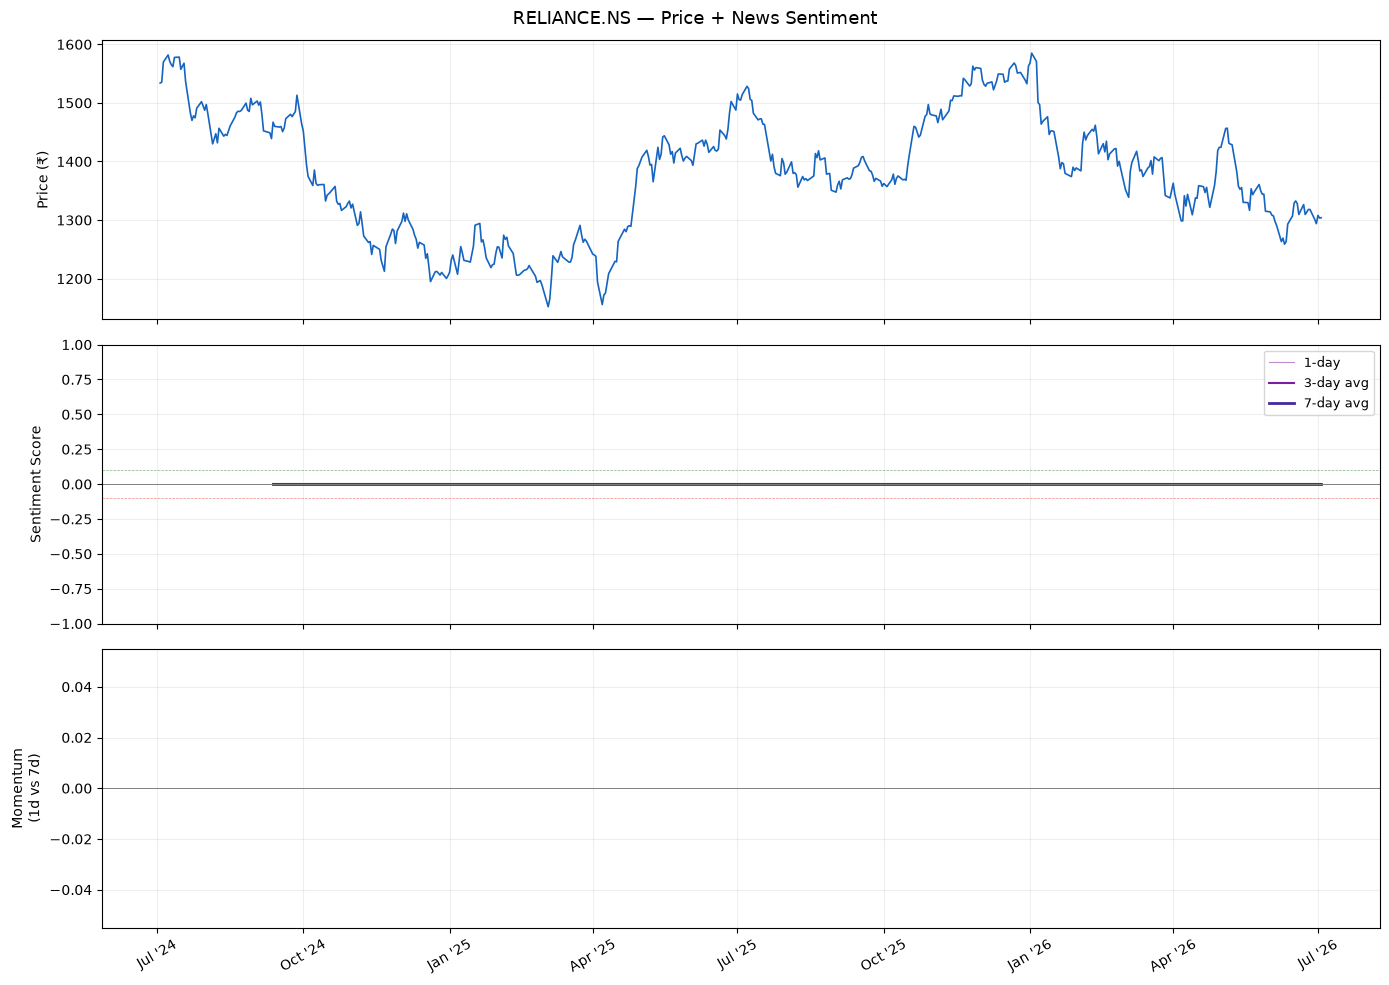

Chart saved.


In [7]:
prices = load_prices(TICKER)
df_viz = df.dropna(subset=["sentiment_3d"])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"{TICKER} — Price + News Sentiment", fontsize=13)

# Price
ax1 = axes[0]
ax1.plot(prices.index, prices["Close"],
         color="#1565C0", lw=1.2)
ax1.set_ylabel("Price (₹)")
ax1.grid(alpha=0.2)

# Sentiment scores
ax2 = axes[1]
ax2.plot(df_viz.index, df_viz["sentiment_1d"],
         color="#7B1FA2", lw=0.8, alpha=0.5, label="1-day")
ax2.plot(df_viz.index, df_viz["sentiment_3d"],
         color="#7B1FA2", lw=1.5, label="3-day avg")
ax2.plot(df_viz.index, df_viz["sentiment_7d"],
         color="#4527A0", lw=2,   label="7-day avg")
ax2.axhline(0,    color="gray",    lw=0.7)
ax2.axhline( 0.1, color="#2E7D32", lw=0.5,
             linestyle="--", alpha=0.6)
ax2.axhline(-0.1, color="#E53935", lw=0.5,
             linestyle="--", alpha=0.6)
ax2.fill_between(df_viz.index, df_viz["sentiment_3d"], 0,
                  where=(df_viz["sentiment_3d"] > 0),
                  color="#2E7D32", alpha=0.15)
ax2.fill_between(df_viz.index, df_viz["sentiment_3d"], 0,
                  where=(df_viz["sentiment_3d"] < 0),
                  color="#E53935", alpha=0.15)
ax2.set_ylabel("Sentiment Score")
ax2.set_ylim(-1, 1)
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(alpha=0.2)

# Momentum
ax3 = axes[2]
colours = ["#2E7D32" if v > 0 else "#E53935"
           for v in df_viz["sentiment_momentum"]]
ax3.bar(df_viz.index, df_viz["sentiment_momentum"],
        color=colours, alpha=0.7, width=1)
ax3.axhline(0, color="gray", lw=0.7)
ax3.set_ylabel("Momentum\n(1d vs 7d)")
ax3.grid(alpha=0.2)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../data/charts/sentiment_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

Today's sentiment summary

In [8]:
# This is what the /sentiment/{ticker} API endpoint returns
last = df.iloc[-1]
from src.sentiment.aggregator import sentiment_to_text

print(f"\n{'═'*50}")
print(f"  TODAY'S SENTIMENT — {TICKER}")
print(f"{'═'*50}")
print(f"  1-day score  : {last['sentiment_1d']:+.4f}  "
      f"({sentiment_to_text(last['sentiment_1d'])})")
print(f"  3-day avg    : {last['sentiment_3d']:+.4f}  "
      f"({sentiment_to_text(last['sentiment_3d'])})")
print(f"  7-day avg    : {last['sentiment_7d']:+.4f}  "
      f"({sentiment_to_text(last['sentiment_7d'])})")
print(f"  Momentum     : {last['sentiment_momentum']:+.4f}  "
      f"({'improving' if last['sentiment_momentum'] > 0 else 'deteriorating'})")
print(f"\n  This structured output feeds directly into")
print(f"  the LLM explanation layer in Week 8.")


══════════════════════════════════════════════════
  TODAY'S SENTIMENT — RELIANCE.NS
══════════════════════════════════════════════════
  1-day score  : +0.0000  (NEUTRAL)
  3-day avg    : +0.0000  (NEUTRAL)
  7-day avg    : +0.0000  (NEUTRAL)
  Momentum     : +0.0000  (deteriorating)

  This structured output feeds directly into
  the LLM explanation layer in Week 8.
